In [1]:
#load the data of neg, pos, and combined windows

import pandas as pd

window_label = ["5kb","10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

cor_all_df_neg = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/all_correlation_neg_df_ct_time_results.csv")
cor_all_df_pos = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/all_correlation_pos_df_ct_time_results.csv")
cor_all_df_combined = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/all_correlation_range_df_ct_time_results.csv")

In [2]:
cor_all_df_combined.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj
0,5kb,a1cf,12-6176521-6177141,0.315765,0.000007,5.184779,0.000035,4.452781
1,5kb,a1cf,12-6174866-6175973,0.243407,0.000587,3.231693,0.002064,2.685358
2,5kb,a1cf,12-6181654-6182495,0.125627,0.079348,1.100462,0.143603,0.842836
3,5kb,a1cf,12-6180312-6181218,0.120367,0.092865,1.032148,0.163485,0.786523
4,5kb,a1cf,12-6177594-6178380,0.263292,0.000193,3.715322,0.000762,3.118305


In [3]:
print(len(cor_all_df_pos["gene"].unique()))
print(len(cor_all_df_neg["gene"].unique()))
print(len(cor_all_df_combined["gene"].unique()))

19162
19161
19166


In [4]:
print(cor_all_df_neg.head())
print(cor_all_df_pos.head())
print(cor_all_df_combined.head())

  window   gene           peak  correlation        pvalue  neglog10_pvalue  \
0    5kb  rpl24  1-11007-12962    -0.304377  1.441907e-05         4.841063   
1    5kb  rpl24  1-13276-13705    -0.193392  6.610336e-03         2.179776   
2    5kb  rpl24  1-14059-14260    -0.484422  6.294299e-13        12.201053   
3    5kb  rpl24  1-14625-15105    -0.435176  1.841421e-10         9.734847   
4    5kb  rpl24  1-15724-15934    -0.247289  4.752497e-04         3.323078   

           padj  neglog10_padj  
0  6.728626e-05       4.172074  
1  1.672261e-02       1.776696  
2  9.140804e-12      11.039016  
3  1.892239e-09       8.723024  
4  1.613888e-03       2.792127  
  window   gene           peak  correlation        pvalue  neglog10_pvalue  \
0    5kb  rpl24    1-9541-9969    -0.148999  3.713353e-02         1.430234   
1    5kb  cep97  1-13276-13705     0.285249  5.068191e-05         4.295147   
2    5kb  cep97  1-14059-14260     0.596123  3.032682e-20        19.518173   
3    5kb  cep97  1-14

In [8]:
# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_all_df_neg["category"] = cor_all_df_neg.apply(classify_pair, axis=1)
cor_all_df_pos["category"] = cor_all_df_pos.apply(classify_pair, axis=1)
cor_all_df_combined["category"] = cor_all_df_combined.apply(classify_pair, axis=1)

# Assignments between increasing windows respectively (pos/neg windows)

Downstream (pos) windows

In [9]:
import numpy as np
import pandas as pd

#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

In [10]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the cor results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_pos = cor_all_df_pos[cor_all_df_pos["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_pos = {}

for window in window_sizes:
    sig_peaks_by_gene_window_pos[window] = {}
    window_df = sig_df_pos[sig_df_pos["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_pos[window][gene_id] = group["peak"].tolist()

In [11]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe

print(sig_peaks_by_gene_window_pos["10kb"]["rpl24"])
print(cor_all_df_pos[(cor_all_df_pos["gene"] == "rpl24") & (cor_all_df_pos["window"] == "10kb") & (cor_all_df_pos["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['1-2372-3057', '1-3427-4032']
['1-2372-3057', '1-3427-4032']


In [12]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_pos["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_pos["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: a1cf
peaks: ['12-6168075-6169044', '12-6169328-6170580', '12-6171543-6171943', '12-6174866-6175973', '12-6176521-6177141']
n peaks: 5
n unique peaks: 5
jaccard with itself: 1.0


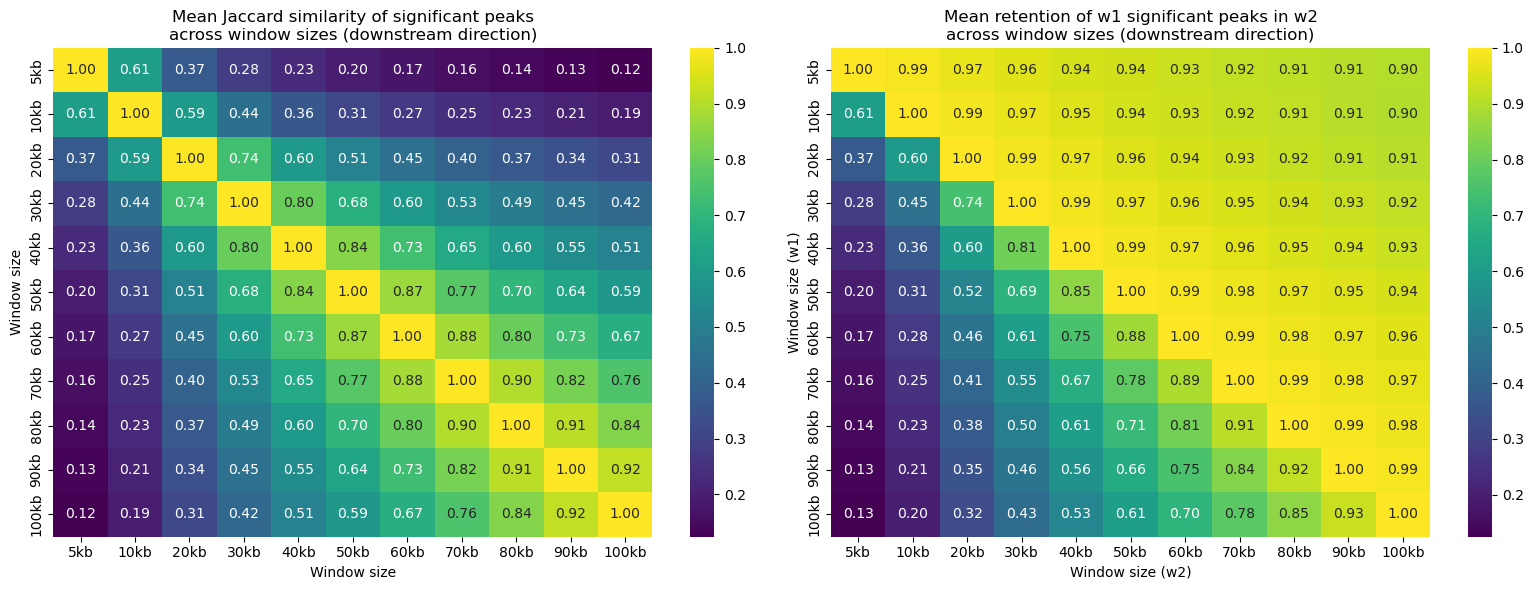

In [13]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(cor_all_df_pos["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_pos[w1].get(gene, []),
                sig_peaks_by_gene_window_pos[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pos[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_pos[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_pos[w1].get(gene, []),
                sig_peaks_by_gene_window_pos[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pos[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_pos[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (downstream direction)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (downstream direction)")

plt.tight_layout()

Upstream (neg) windows

In [14]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the cor results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_neg = cor_all_df_neg[cor_all_df_neg["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_neg = {}

for window in window_sizes:
    sig_peaks_by_gene_window_neg[window] = {}
    window_df = sig_df_neg[sig_df_neg["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_neg[window][gene_id] = group["peak"].tolist()

In [15]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
print(sig_peaks_by_gene_window_neg["10kb"]["abcc10"])
print(cor_all_df_neg[(cor_all_df_neg["gene"] == "abcc10") & (cor_all_df_neg["window"] == "10kb") & (cor_all_df_neg["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['11-11965923-11966247']
['11-11965923-11966247']


In [16]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_neg["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_neg["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: a1cf
peaks: ['12-6177594-6178380', '12-6182609-6183304', '12-6186318-6186534', '12-6186644-6187111']
n peaks: 4
n unique peaks: 4
jaccard with itself: 1.0


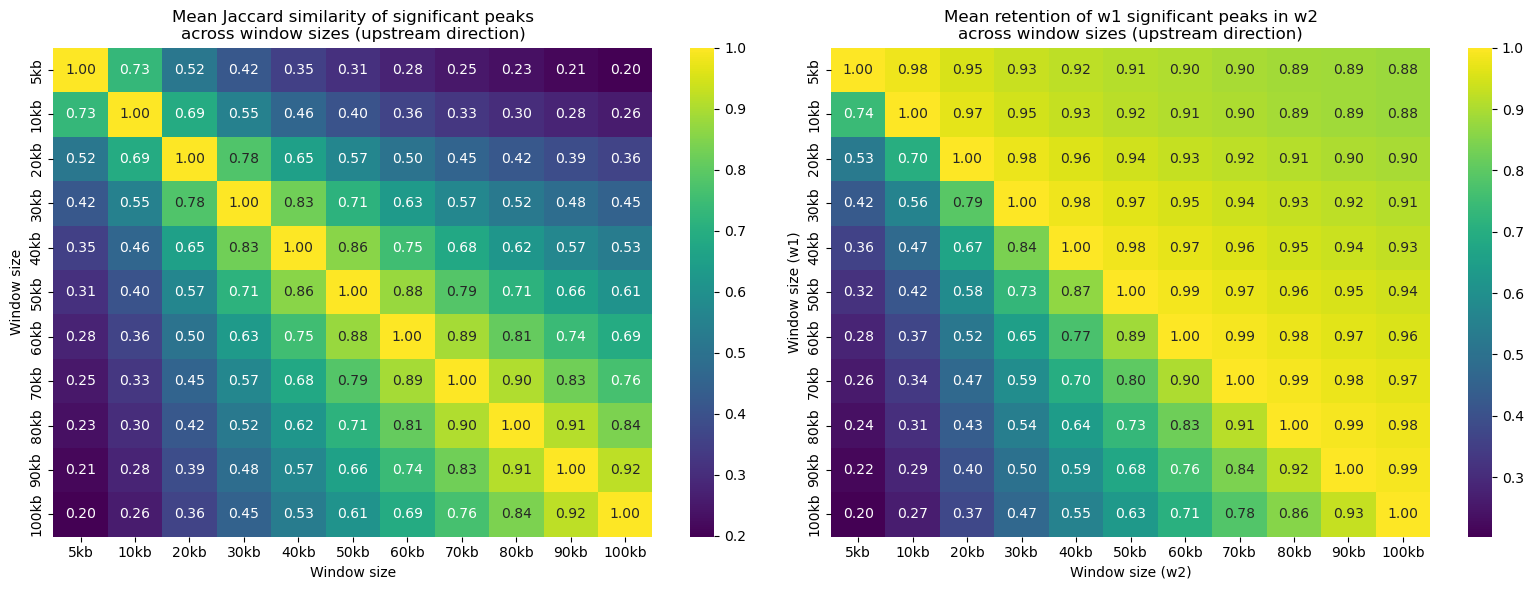

In [17]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(cor_all_df_neg["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_neg[w1].get(gene, []),
                sig_peaks_by_gene_window_neg[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_neg[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_neg[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_neg[w1].get(gene, []),
                sig_peaks_by_gene_window_neg[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_neg[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_neg[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (upstream direction)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (upstream direction)")

plt.tight_layout()


Overlap window around TSS

In [18]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the cor results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_combined = cor_all_df_combined[cor_all_df_combined["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_combined = {}

for window in window_sizes:
    sig_peaks_by_gene_window_combined[window] = {}
    window_df = sig_df_combined[sig_df_combined["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_combined[window][gene_id] = group["peak"].tolist()

In [19]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
print(sig_peaks_by_gene_window_combined["10kb"]["abcc10"])
print(cor_all_df_combined[(cor_all_df_combined["gene"] == "abcc10") & (cor_all_df_combined["window"] == "10kb") & (cor_all_df_combined["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['11-11965923-11966247', '11-11960861-11961873']
['11-11965923-11966247', '11-11960861-11961873']


In [20]:
# pick any gene and check its 10kb peaks compared to itself
gene = list(sig_peaks_by_gene_window_combined["10kb"].keys())[0]
peaks = sig_peaks_by_gene_window_combined["10kb"][gene]
print(f"gene: {gene}")
print(f"peaks: {peaks}")
print(f"n peaks: {len(peaks)}")
print(f"n unique peaks: {len(set(peaks))}")
print(f"jaccard with itself: {jaccard(peaks, peaks)}")

gene: a1cf
peaks: ['12-6186644-6187111', '12-6174866-6175973', '12-6176521-6177141', '12-6169328-6170580', '12-6186318-6186534', '12-6168075-6169044', '12-6171543-6171943', '12-6177594-6178380', '12-6182609-6183304']
n peaks: 9
n unique peaks: 9
jaccard with itself: 1.0


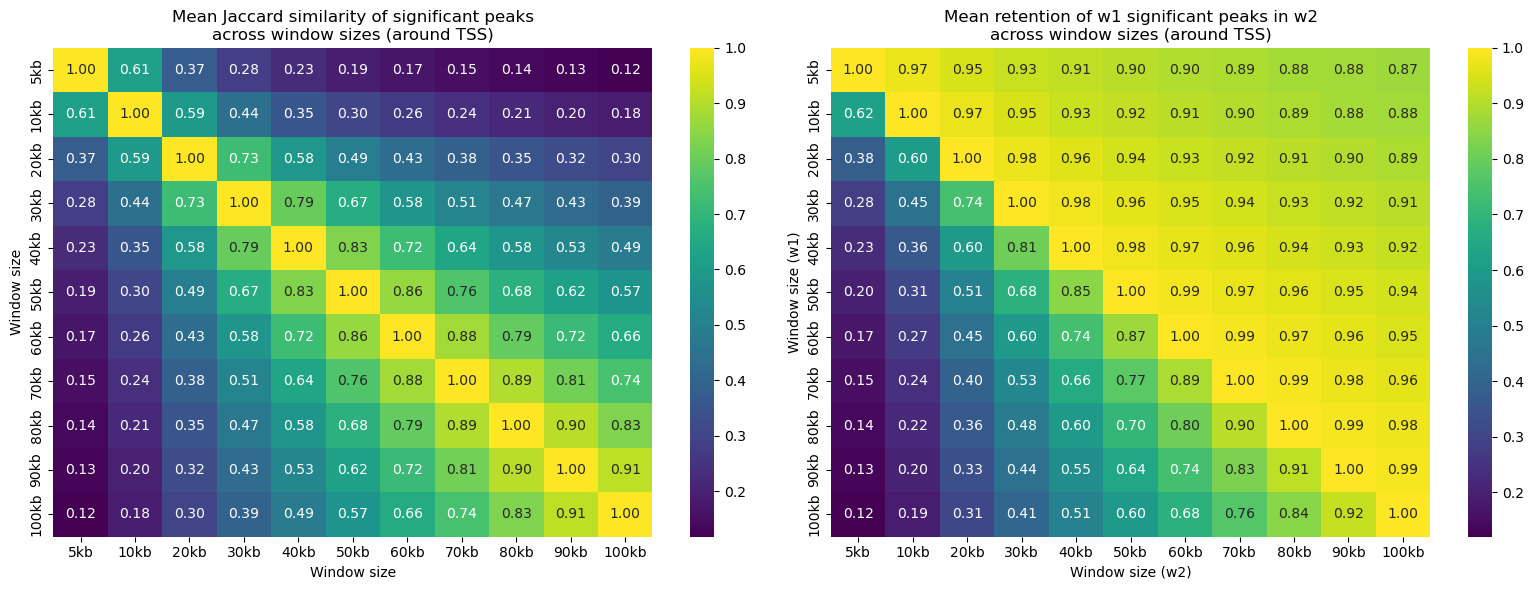

In [21]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(cor_all_df_combined["gene"].unique())

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_combined[w1].get(gene, []),
                sig_peaks_by_gene_window_combined[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_combined[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_combined[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from w1 are retained in w2) ---
retention_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_combined[w1].get(gene, []),
                sig_peaks_by_gene_window_combined[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_combined[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_combined[w2].get(gene, [])) > 0
        ]
        retention_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of significant peaks\nacross window sizes (around TSS)")

sns.heatmap(retention_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (w2)")
axes[1].set_ylabel("Window size (w1)")
axes[1].set_title("Mean retention of w1 significant peaks in w2\nacross window sizes (around TSS)")

plt.tight_layout()

# Assignments between neg. + pos. windows and combined window

In [22]:
#merge both datasets of monodirectional dfs 
combined_df = pd.concat([cor_all_df_neg, cor_all_df_pos], ignore_index=True)
combined_df.head()

#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe
gene_id = "rpl24"
window = "10kb"

sig_peaks_list = list(set(cor_all_df_neg[(cor_all_df_neg["window"] == window) & (cor_all_df_neg["gene"] == gene_id)]["peak"].tolist()) | set(cor_all_df_pos[(cor_all_df_pos["window"] == window) & (cor_all_df_pos["gene"] == gene_id)]["peak"].tolist()))
sig_peaks_df = combined_df[(combined_df["gene"] == gene_id) & (combined_df["window"] == window)]["peak"].tolist()

print(f"Significant peaks for {gene_id} in {window}: sig_peaks_list: {sig_peaks_list}")
print(f"From dataframe: {sig_peaks_df}")


Significant peaks for rpl24 in 10kb: sig_peaks_list: ['1-15724-15934', '1-16762-17233', '1-4469-7268', '1-3427-4032', '1-14625-15105', '1-18372-20466', '1-21199-21555', '1-13276-13705', '1-17587-18215', '1-2372-3057', '1-9541-9969', '1-11007-12962', '1-14059-14260']
From dataframe: ['1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105', '1-15724-15934', '1-16762-17233', '1-17587-18215', '1-18372-20466', '1-21199-21555', '1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969']


In [23]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the ols results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_pseudo = combined_df[combined_df["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_window_pseudo = {}

for window in window_sizes:
    sig_peaks_by_gene_window_pseudo[window] = {}
    window_df = sig_df_pseudo[sig_df_pseudo["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_pseudo[window][gene_id] = group["peak"].tolist()

In [ ]:
#sanity check: compare the significant peaks for a specific gene and window size between the list and the dataframe

print(sig_peaks_by_gene_window_pseudo["10kb"]["rpl24"])
print(combined_df[(combined_df["gene"] == "rpl24") & (combined_df["window"] == "10kb") & (combined_df["category"].isin(["sig. negative", "sig. positive"]))]["peak"].tolist())

['1-4469-7268', '1-9541-9969']
['1-4469-7268', '1-9541-9969']


In [24]:
#create a dictionary with the significant peaks for each gene for each window size, by filtering the cor results for significant peaks and grouping by gene and window size, and saving the significant peaks in a list for each gene and window size
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

sig_df_real = cor_all_df_combined[cor_all_df_combined["category"].isin(["sig. negative", "sig. positive"])]

sig_peaks_by_gene_window_real = {}

for window in window_sizes:
    sig_peaks_by_gene_window_real[window] = {}
    window_df = sig_df_real[sig_df_real["window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_window_real[window][gene_id] = group["peak"].tolist()

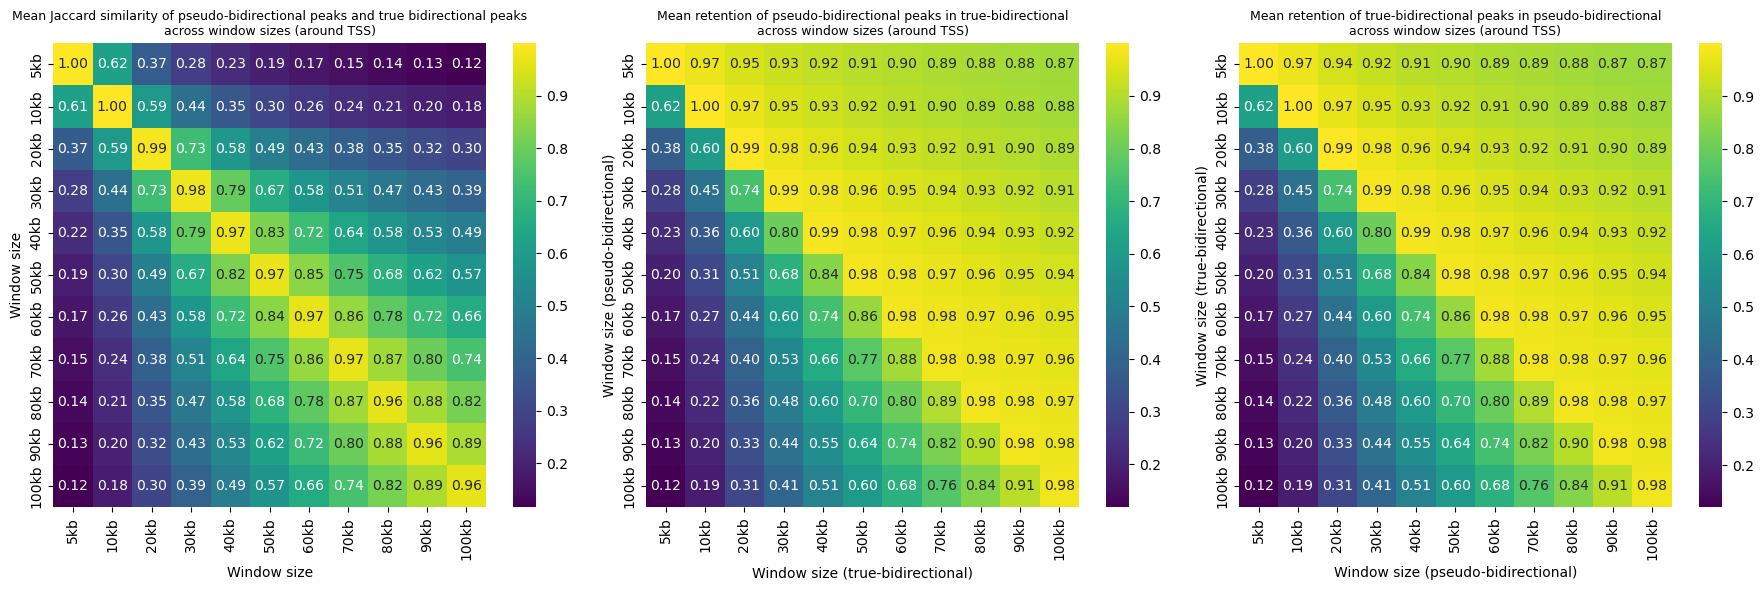

In [25]:
#create a heatmap of the mean retention for each pair of window sizes, by calculating the retention for each gene and averaging across all genes for each pair of window sizes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

all_genes = set(cor_all_df_combined["gene"].unique()) | set(combined_df["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

# --- Jaccard matrix ---
jaccard_matrix = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            jaccard( #compute gene-wise jaccard similarity between the significant peaks for the two window sizes, only for genes that have significant peaks in both window sizes
                sig_peaks_by_gene_window_pseudo[w1].get(gene, []),
                sig_peaks_by_gene_window_real[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pseudo[w1].get(gene, [])) > 0  #only consider genes that have significant peaks in both window sizes
            and len(sig_peaks_by_gene_window_real[w2].get(gene, [])) > 0
        ]
        jaccard_matrix.loc[w1, w2] = np.mean(scores) if scores else np.nan #average the jaccard similarity across all genes for the pair of window sizes, and store in the matrix

# --- Retention matrix (how many peaks from pseudo-bidirectional are retained in true bidirectional) ---
retention_matrix_pt = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_pseudo[w1].get(gene, []),
                sig_peaks_by_gene_window_real[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_pseudo[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_real[w2].get(gene, [])) > 0
        ]
        retention_matrix_pt.loc[w1, w2] = np.mean(scores) if scores else np.nan 

# --- Retention matrix (how many peaks from true bidirectional are retained in pseudo-bidirectional) ---
retention_matrix_tb = pd.DataFrame(index=window_sizes, columns=window_sizes, dtype=float)

for w1 in window_sizes:
    for w2 in window_sizes:
        scores = [
            retention(
                sig_peaks_by_gene_window_real[w1].get(gene, []),
                sig_peaks_by_gene_window_pseudo[w2].get(gene, [])
            )
            for gene in all_genes
            if len(sig_peaks_by_gene_window_real[w1].get(gene, [])) > 0
            and len(sig_peaks_by_gene_window_pseudo[w2].get(gene, [])) > 0
        ]
        retention_matrix_tb.loc[w1, w2] = np.mean(scores) if scores else np.nan 
# --- Plot side by side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("Window size")
axes[0].set_title("Mean Jaccard similarity of pseudo-bidirectional peaks and true bidirectional peaks\nacross window sizes (around TSS)", fontsize=9)

sns.heatmap(retention_matrix_pt.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Window size (true-bidirectional)") 
axes[1].set_ylabel("Window size (pseudo-bidirectional)")
axes[1].set_title("Mean retention of pseudo-bidirectional peaks in true-bidirectional\nacross window sizes (around TSS)", fontsize=9)

sns.heatmap(retention_matrix_tb.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[2])
axes[2].set_xlabel("Window size (pseudo-bidirectional)") 
axes[2].set_ylabel("Window size (true-bidirectional)") 
axes[2].set_title("Mean retention of true-bidirectional peaks in pseudo-bidirectional\nacross window sizes (around TSS)", fontsize=9)

plt.tight_layout()